# Notebook 1: Data Preprocessing for SWaT CPS Telemetry

**Course Project: AI-Driven Threat Modeling for Resilient Cyber–Physical Systems**

---

## Objective

This notebook prepares the **Secure Water Treatment (SWaT)** time-series dataset for adversarial behavior learning.

**Scope:**
- Load SWaT sensor/actuator telemetry data
- Explore CPS-specific data characteristics
- Clean, normalize, and engineer features
- Create sliding temporal windows for LSTM input
- Map features to physical CPS components
- Prepare train/test splits with attack labels

**Out of Scope:**
- Model training
- Threat integration

**Key Principle:**
This is **CPS telemetry**, not generic tabular data. Preprocessing decisions must respect:
- Physical process dynamics
- Sensor/actuator relationships
- Temporal dependencies
- Attack patterns specific to industrial control systems

---

## 1. Understanding the SWaT Dataset

### 1.1 Dataset Overview

The SWaT dataset contains time-series measurements from a water treatment testbed during:
- **Normal operation:** 7 days of continuous operation
- **Attack scenarios:** 36 attack scenarios over 4 days

**Data Structure:**
- **Timestamps:** 1-second sampling interval
- **Features:** ~51 sensor and actuator readings
- **Labels:** Binary (Normal = 0, Attack = 1)

### 1.2 Feature Categories

| Category | Description | Examples |
|----------|-------------|----------|
| **Sensors** | Measure physical quantities | Water level (LIT), flow rate (FIT), pressure (P) |
| **Actuators** | Control physical processes | Pumps (P), motorized valves (MV) |
| **Analyzers** | Chemical/quality measurements | pH, conductivity, chlorine (AIT) |

### 1.3 Attack Types in SWaT Dataset

The dataset includes attacks targeting:
- **Single-stage attacks:** Compromise one process stage (e.g., P1)
- **Multi-stage attacks:** Coordinated attacks across stages
- **Stealthy attacks:** Minimal deviation from normal behavior
- **Direct attacks:** Aggressive process manipulation

**Important:** Attack labels indicate when the system is **under attack**, not when anomalies become visible. This temporal lag is critical for detection system evaluation.

---

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
import os
import json

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully
NumPy version: 1.26.4
Pandas version: 2.2.3


---

## 2. Data Loading and Initial Exploration

### 2.1 Load SWaT Dataset

We'll load the dataset from the `SWAT_dataset` directory. The dataset typically includes:
- `normal.csv`: Normal operation data
- `attack.csv`: Data with attack scenarios
- `merged.csv`: Combined dataset (if available)

In [2]:
# Define data directory
data_dir = 'SWAT_dataset'

# Check available files
print("Available files in SWAT_dataset:")
for file in os.listdir(data_dir):
    if file.endswith('.csv'):
        file_path = os.path.join(data_dir, file)
        file_size = os.path.getsize(file_path) / (1024 * 1024)  # MB
        print(f"  - {file} ({file_size:.2f} MB)")

Available files in SWAT_dataset:
  - merged.csv (407.08 MB)
  - attack.csv (14.46 MB)
  - normal.csv (383.73 MB)


In [3]:
# Load the datasets
print("Loading SWaT datasets...\n")

# Try loading merged dataset first, otherwise load separately
try:
    df = pd.read_csv(os.path.join(data_dir, 'merged.csv'))
    print(f"✓ Loaded merged dataset: {df.shape}")
    data_source = "merged"
except FileNotFoundError:
    # Load normal and attack separately
    df_normal = pd.read_csv(os.path.join(data_dir, 'normal.csv'))
    df_attack = pd.read_csv(os.path.join(data_dir, 'attack.csv'))
    
    print(f"✓ Loaded normal.csv: {df_normal.shape}")
    print(f"✓ Loaded attack.csv: {df_attack.shape}")
    
    # Combine datasets
    df = pd.concat([df_normal, df_attack], axis=0, ignore_index=True)
    print(f"✓ Combined dataset: {df.shape}")
    data_source = "separate"

print(f"\nDataset loaded from: {data_source}")
print(f"Total samples: {len(df):,}")
print(f"Total features: {df.shape[1]}")

Loading SWaT datasets...

✓ Loaded merged dataset: (1441719, 53)

Dataset loaded from: merged
Total samples: 1,441,719
Total features: 53


In [4]:
# Display first few rows
print("First 5 rows of the dataset:\n")
print(df.head())

print("\n" + "="*80)
print("Last 5 rows of the dataset:\n")
print(df.tail())

First 5 rows of the dataset:

                 Timestamp    FIT101    LIT101   MV101  P101  P102    AIT201  \
0   28/12/2015 10:00:00 AM  2.427057  522.8467     2.0     2     1  262.0161   
1   28/12/2015 10:00:01 AM  2.446274  522.8860     2.0     2     1  262.0161   
2   28/12/2015 10:00:02 AM  2.489191  522.8467     2.0     2     1  262.0161   
3   28/12/2015 10:00:03 AM  2.534350  522.9645     2.0     2     1  262.0161   
4   28/12/2015 10:00:04 AM  2.569260  523.4748     2.0     2     1  262.0161   

     AIT202    AIT203    FIT201  ...  P501  P502    PIT501    PIT502  \
0  8.396437  328.6337  2.445391  ...     2     1  250.8652  1.649953   
1  8.396437  328.6337  2.445391  ...     2     1  250.8652  1.649953   
2  8.394514  328.6337  2.442316  ...     2     1  250.8812  1.649953   
3  8.394514  328.6337  2.442316  ...     2     1  250.8812  1.649953   
4  8.394514  328.6337  2.443085  ...     2     1  250.8812  1.649953   

     PIT503    FIT601  P601  P602  P603  Normal/Attack  

In [5]:
# Check data types and missing values
print("Dataset Information:\n")
print(df.info())

print("\n" + "="*80)
print("Missing Values Summary:\n")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0].sort_values(ascending=False))
else:
    print("✓ No missing values detected")

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441719 entries, 0 to 1441718
Data columns (total 53 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0    Timestamp     1441719 non-null  object 
 1   FIT101         1441719 non-null  float64
 2   LIT101         1441719 non-null  float64
 3    MV101         449919 non-null   float64
 4   P101           1441719 non-null  int64  
 5   P102           1441719 non-null  int64  
 6    AIT201        449919 non-null   float64
 7   AIT202         1441719 non-null  float64
 8   AIT203         1441719 non-null  float64
 9   FIT201         1441719 non-null  float64
 10   MV201         449919 non-null   float64
 11   P201          449919 non-null   float64
 12   P202          449919 non-null   float64
 13  P203           1441719 non-null  int64  
 14   P204          449919 non-null   float64
 15  P205           1441719 non-null  int64  
 16  P206           1441719 non-null 

### 2.2 Feature Analysis

Let's identify and categorize the features based on SWaT naming conventions:

**Naming Patterns:**
- **LIT**: Level Indicator Transmitter (water level sensors)
- **FIT**: Flow Indicator Transmitter (flow rate sensors)
- **AIT**: Analyzer Indicator Transmitter (chemical analyzers)
- **P**: Pump (binary actuator)
- **MV**: Motorized Valve (binary actuator)
- **UV**: UV lamp (binary actuator)
- **DPIT**: Differential Pressure Indicator Transmitter

In [6]:
# Get column names (excluding timestamp and label columns)
columns = df.columns.tolist()
print(f"Total columns: {len(columns)}\n")

# Identify potential timestamp and label columns
timestamp_cols = [col for col in columns if 'time' in col.lower() or 'date' in col.lower()]
label_cols = [col for col in columns if 'attack' in col.lower() or 'normal' in col.lower() or 'label' in col.lower()]

print(f"Timestamp columns: {timestamp_cols}")
print(f"Label columns: {label_cols}")

# Feature columns are all except timestamp and label
feature_cols = [col for col in columns if col not in timestamp_cols and col not in label_cols]
print(f"\nFeature columns: {len(feature_cols)}")
print(feature_cols[:20], "..." if len(feature_cols) > 20 else "")

Total columns: 53

Timestamp columns: [' Timestamp']
Label columns: ['Normal/Attack']

Feature columns: 51
['FIT101', 'LIT101', ' MV101', 'P101', 'P102', ' AIT201', 'AIT202', 'AIT203', 'FIT201', ' MV201', ' P201', ' P202', 'P203', ' P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301'] ...


In [7]:
# Categorize features by type based on naming conventions

def categorize_swat_features(columns):
    """
    Categorize SWaT features into sensors, actuators, and analyzers
    based on naming conventions.
    """
    categories = {
        'level_sensors': [],      # LIT - water level
        'flow_sensors': [],        # FIT - flow rate
        'pressure_sensors': [],    # DPIT, PIT - pressure
        'analyzers': [],           # AIT - chemical analyzers
        'pumps': [],               # P - pumps
        'valves': [],              # MV - motorized valves
        'other_actuators': [],     # UV, etc.
        'other': []
    }
    
    for col in columns:
        col_upper = col.upper()
        
        if 'LIT' in col_upper:
            categories['level_sensors'].append(col)
        elif 'FIT' in col_upper:
            categories['flow_sensors'].append(col)
        elif 'PIT' in col_upper or 'DPIT' in col_upper:
            categories['pressure_sensors'].append(col)
        elif 'AIT' in col_upper:
            categories['analyzers'].append(col)
        elif col_upper.startswith('P-') or (col_upper.startswith('P') and len(col) <= 4):
            categories['pumps'].append(col)
        elif 'MV' in col_upper:
            categories['valves'].append(col)
        elif 'UV' in col_upper:
            categories['other_actuators'].append(col)
        else:
            categories['other'].append(col)
    
    return categories

# Categorize features
feature_categories = categorize_swat_features(feature_cols)

print("SWaT Feature Categorization:\n")
for category, features in feature_categories.items():
    if features:
        print(f"{category.upper().replace('_', ' ')}: {len(features)}")
        print(f"  {features[:5]}{'...' if len(features) > 5 else ''}")
        print()

SWaT Feature Categorization:

LEVEL SENSORS: 3
  ['LIT101', 'LIT301', 'LIT401']

FLOW SENSORS: 9
  ['FIT101', 'FIT201', 'FIT301', 'FIT401', 'FIT501']...

PRESSURE SENSORS: 4
  ['DPIT301', 'PIT501', 'PIT502', 'PIT503']

ANALYZERS: 9
  [' AIT201', 'AIT202', 'AIT203', 'AIT401', 'AIT402']...

PUMPS: 16
  ['P101', 'P102', 'P203', 'P205', 'P206']...

VALVES: 6
  [' MV101', ' MV201', 'MV301', 'MV302', ' MV303']...

OTHER ACTUATORS: 1
  ['UV401']

OTHER: 3
  [' P201', ' P202', ' P204']



In [8]:
# Map features to SWaT process stages (P1-P6)

def map_to_process_stages(columns):
    """
    Map features to SWaT process stages based on numbering.
    """
    stages = {f'P{i}': [] for i in range(1, 7)}
    stages['Unassigned'] = []
    
    for col in columns:
        assigned = False
        for stage in range(1, 7):
            # Look for P1, P2, etc. in column name
            if f'{stage}' in col or f'_{stage}' in col or f'-{stage}' in col:
                stages[f'P{stage}'].append(col)
                assigned = True
                break
        
        if not assigned:
            stages['Unassigned'].append(col)
    
    return stages

# Map to stages
feature_stages = map_to_process_stages(feature_cols)

print("Feature Distribution Across Process Stages:\n")
for stage, features in feature_stages.items():
    if features:
        print(f"{stage}: {len(features)} features")
        if len(features) <= 8:
            print(f"  {features}")
        else:
            print(f"  {features[:4]} ... {features[-2:]}")
        print()

Feature Distribution Across Process Stages:

P1: 25 features
  ['FIT101', 'LIT101', ' MV101', 'P101'] ... ['FIT601', 'P601']

P2: 16 features
  ['AIT202', 'AIT203', ' P202', 'P203'] ... ['PIT502', 'P602']

P3: 7 features
  [' MV303', 'MV304', 'P403', 'AIT503', 'FIT503', 'PIT503', 'P603']

P4: 3 features
  ['P404', 'AIT504', 'FIT504']



---

## 3. Data Quality Assessment

### 3.1 Statistical Summary

Understanding the range and distribution of CPS telemetry is critical for:
- Detecting sensor malfunctions
- Identifying physical constraints
- Setting normalization bounds

In [9]:
# Statistical summary of features
print("Statistical Summary of Features:\n")
print(df[feature_cols].describe().T)

Statistical Summary of Features:

             count        mean         std         min         25%  \
FIT101   1441719.0    1.806108    1.153932    0.000000    0.000000   
LIT101   1441719.0  593.120048  123.932458  120.623700  508.794300   
 MV101    449919.0    1.665335    0.482323    0.000000    1.000000   
P101     1441719.0    1.730916    0.443484    1.000000    1.000000   
P102     1441719.0    1.002168    0.046507    1.000000    1.000000   
 AIT201   449919.0  210.297302   35.157909  168.033800  177.102000   
AIT202   1441719.0    8.431862    0.118139    6.000000    8.357024   
AIT203   1441719.0  339.565826   43.999077  285.337100  321.148400   
FIT201   1441719.0    1.791239    1.084655    0.000000    0.000000   
 MV201    449919.0    1.691584    0.470611    0.000000    1.000000   
 P201     449919.0    1.121068    0.326207    1.000000    1.000000   
 P202     449919.0    1.000000    0.000000    1.000000    1.000000   
P203     1441719.0    1.728808    0.444575    1.000000  

In [10]:
# Identify binary (actuator) vs continuous (sensor) features

def identify_feature_types(df, feature_cols):
    """
    Classify features as binary (actuators) or continuous (sensors).
    """
    binary_features = []
    continuous_features = []
    
    for col in feature_cols:
        unique_vals = df[col].nunique()
        
        # Binary features typically have 2-3 unique values (0, 1, sometimes 2)
        if unique_vals <= 3 and df[col].dtype in ['int64', 'float64']:
            # Check if values are only 0s and 1s (or 2s)
            unique_set = set(df[col].dropna().unique())
            if unique_set.issubset({0, 1, 2, 0.0, 1.0, 2.0}):
                binary_features.append(col)
            else:
                continuous_features.append(col)
        else:
            continuous_features.append(col)
    
    return binary_features, continuous_features

binary_features, continuous_features = identify_feature_types(df, feature_cols)

print(f"Feature Type Classification:\n")
print(f"Binary features (actuators): {len(binary_features)}")
print(f"  {binary_features[:10]}{'...' if len(binary_features) > 10 else ''}\n")
print(f"Continuous features (sensors): {len(continuous_features)}")
print(f"  {continuous_features[:10]}{'...' if len(continuous_features) > 10 else ''}")

Feature Type Classification:

Binary features (actuators): 26
  [' MV101', 'P101', 'P102', ' MV201', ' P201', ' P202', 'P203', ' P204', 'P205', 'P206']...

Continuous features (sensors): 25
  ['FIT101', 'LIT101', ' AIT201', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401']...


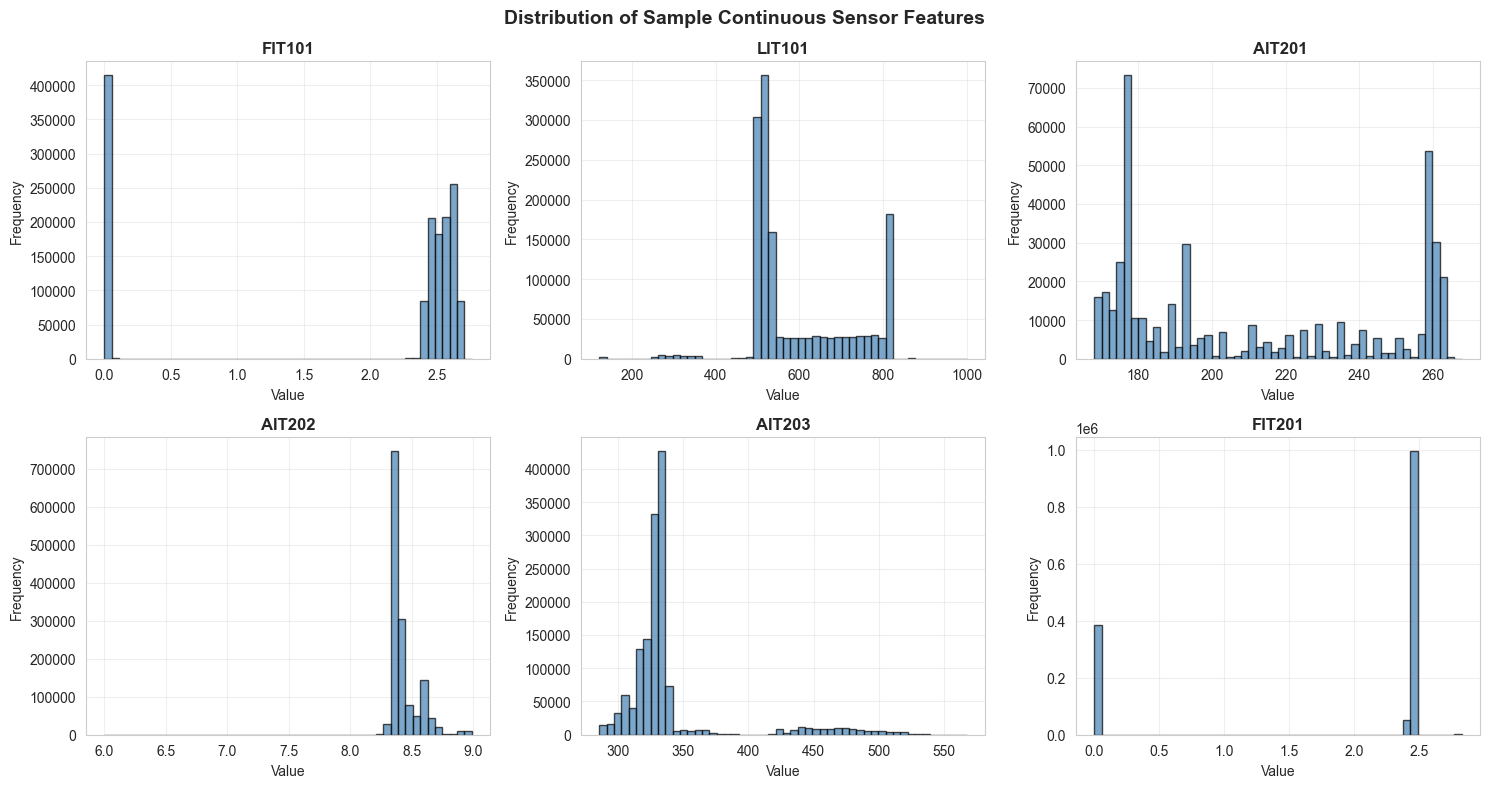

In [11]:
# Visualize distribution of continuous sensor features (sample)

sample_sensors = continuous_features[:6]  # First 6 continuous features

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(sample_sensors):
    axes[idx].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.suptitle('Distribution of Sample Continuous Sensor Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Attack Label Analysis

Understanding the distribution of normal vs. attack samples is crucial for:
- Assessing class imbalance
- Designing appropriate sampling strategies
- Evaluating model performance fairly

Label column identified: Normal/Attack

Label Distribution:

Normal/Attack
Normal    1387098
Attack      54621
Name: count, dtype: int64

Label Proportions:

Normal/Attack
Normal    96.211398
Attack     3.788602
Name: proportion, dtype: float64


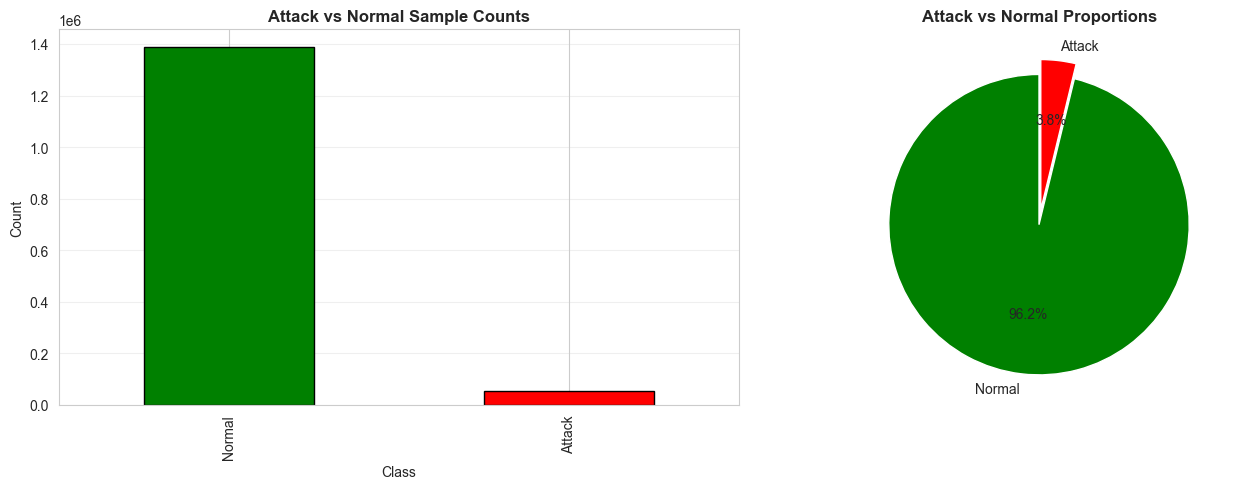

In [12]:
# Identify the label column
# Common names: 'Normal/Attack', 'Attack', 'Label', etc.

label_col = None
for col in df.columns:
    if 'attack' in col.lower() or 'normal' in col.lower() or 'label' in col.lower():
        label_col = col
        break

if label_col is None:
    # If no obvious label column, create one assuming last column or check for binary column
    print("Warning: Label column not automatically identified. Attempting to infer...")
    # Check if any column has only "Normal" and "Attack" values
    for col in df.columns:
        unique_vals = set(df[col].dropna().unique())
        if unique_vals.issubset({'Normal', 'Attack', 'normal', 'attack'}):
            label_col = col
            break
    
    if label_col is None:
        print("Error: Could not identify label column. Please specify manually.")
    else:
        print(f"Inferred label column: {label_col}")
else:
    print(f"Label column identified: {label_col}")

# Display label distribution
if label_col:
    print("\nLabel Distribution:\n")
    label_counts = df[label_col].value_counts()
    print(label_counts)
    
    print("\nLabel Proportions:\n")
    label_props = df[label_col].value_counts(normalize=True) * 100
    print(label_props)
    
    # Visualize label distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    label_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'], edgecolor='black')
    axes[0].set_title('Attack vs Normal Sample Counts', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Proportion plot
    label_props.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['green', 'red'], 
                     startangle=90, explode=[0.05, 0.05])
    axes[1].set_title('Attack vs Normal Proportions', fontweight='bold', fontsize=12)
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()

In [13]:
# Convert label to binary format (0 = Normal, 1 = Attack)

if label_col:
    # Create a standardized binary label column
    df['attack_label'] = df[label_col].apply(
        lambda x: 1 if 'attack' in str(x).lower() else 0
    )
    
    print("Attack label encoding:")
    print(f"  0 = Normal")
    print(f"  1 = Attack")
    print(f"\nEncoded label distribution:")
    print(df['attack_label'].value_counts())
    
    # Update label_col to use the binary version
    label_col = 'attack_label'

Attack label encoding:
  0 = Normal
  1 = Attack

Encoded label distribution:
attack_label
0    1387098
1      54621
Name: count, dtype: int64


---

## 4. Data Cleaning

### 4.1 Handle Missing Values

For CPS data, missing values can indicate:
- Sensor failures
- Communication losses
- Legitimate process states (e.g., equipment offline)

**Strategy:**
- **Forward-fill** for short gaps (assume last valid value persists)
- **Interpolation** for longer gaps (if physically meaningful)
- **Drop** if too many consecutive missing values

In [14]:
# Check for missing values in feature columns
missing_summary = df[feature_cols].isnull().sum()
missing_features = missing_summary[missing_summary > 0]

if len(missing_features) > 0:
    print(f"Features with missing values: {len(missing_features)}\n")
    print(missing_features.sort_values(ascending=False))
    
    # Calculate percentage missing
    print("\nPercentage missing:")
    missing_pct = (missing_features / len(df)) * 100
    print(missing_pct.sort_values(ascending=False))
else:
    print("✓ No missing values in feature columns")

Features with missing values: 7

MV101     991800
AIT201    991800
MV201     991800
P201      991800
P202      991800
P204      991800
MV303     991800
dtype: int64

Percentage missing:
MV101     68.792879
AIT201    68.792879
MV201     68.792879
P201      68.792879
P202      68.792879
P204      68.792879
MV303     68.792879
dtype: float64


In [15]:
# Apply forward-fill for missing values (typical for time-series CPS data)

if len(missing_features) > 0:
    print("Applying forward-fill for missing values...\n")
    
    # Forward fill (carry last observation forward)
    df[feature_cols] = df[feature_cols].fillna(method='ffill')
    
    # Backward fill for any remaining NaN at the start
    df[feature_cols] = df[feature_cols].fillna(method='bfill')
    
    # Check if any NaN remain
    remaining_missing = df[feature_cols].isnull().sum().sum()
    
    if remaining_missing > 0:
        print(f"Warning: {remaining_missing} missing values remain. Filling with 0.")
        df[feature_cols] = df[feature_cols].fillna(0)
    else:
        print("✓ All missing values handled successfully")
else:
    print("✓ No missing value imputation needed")

# Final verification
print(f"\nFinal missing value count: {df[feature_cols].isnull().sum().sum()}")

Applying forward-fill for missing values...

✓ All missing values handled successfully

Final missing value count: 0


### 4.2 Remove Duplicates

Duplicate rows can occur due to:
- Data logging errors
- System restarts with overlapping timestamps

In [16]:
# Check for duplicate rows
initial_rows = len(df)
duplicates = df.duplicated().sum()

print(f"Initial row count: {initial_rows:,}")
print(f"Duplicate rows: {duplicates:,}")

if duplicates > 0:
    print("\nRemoving duplicates...")
    df = df.drop_duplicates()
    final_rows = len(df)
    print(f"✓ Removed {initial_rows - final_rows:,} duplicates")
    print(f"Final row count: {final_rows:,}")
else:
    print("✓ No duplicate rows found")

Initial row count: 1,441,719
Duplicate rows: 494,991

Removing duplicates...
✓ Removed 494,991 duplicates
Final row count: 946,728


### 4.3 Handle Outliers

In CPS data, "outliers" may be:
- **Attack indicators** (should NOT be removed)
- **Sensor malfunctions** (may need capping)
- **Physical impossibilities** (e.g., negative flow rates)

**Strategy:**
- Identify extreme values
- Verify against physical constraints
- Cap only if physically impossible (not if attack-related)

In [17]:
# Identify potential outliers using IQR method (for awareness, not automatic removal)

def detect_outliers_iqr(df, column):
    """Detect outliers using Interquartile Range method."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 3 * IQR  # Using 3*IQR for more conservative outlier detection
    upper_bound = Q3 + 3 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return len(outliers), lower_bound, upper_bound

# Check outliers in continuous features (sample)
print("Outlier Analysis for Sample Continuous Features:\n")
print(f"{'Feature':<20} {'Outliers':<10} {'Lower Bound':<15} {'Upper Bound':<15}")
print("="*70)

sample_continuous = continuous_features[:10]
outlier_summary = []

for col in sample_continuous:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_summary.append({
        'Feature': col,
        'Outliers': n_outliers,
        'Lower_Bound': lower,
        'Upper_Bound': upper
    })
    print(f"{col:<20} {n_outliers:<10} {lower:<15.4f} {upper:<15.4f}")

print("\n⚠️  Note: Outliers in CPS data may indicate attacks and should NOT be automatically removed.")
print("We will preserve all data points for adversarial learning.")

Outlier Analysis for Sample Continuous Features:

Feature              Outliers   Lower Bound     Upper Bound    
FIT101               0          -7.7568         10.3424        
LIT101               0          -72.7353        1284.6249      
 AIT201              1          93.5017         267.5595       
AIT202               199        7.7944          9.1222         
AIT203               69015      273.6479        378.4414       
FIT201               0          -7.3581         9.8108         
DPIT301              215040     17.8917         21.6563        
FIT301               206845     2.1429          2.2685         
LIT301               5726       429.1768        1376.0094      
AIT401               87025      148.7888        148.8224       

⚠️  Note: Outliers in CPS data may indicate attacks and should NOT be automatically removed.
We will preserve all data points for adversarial learning.


---

## 5. Feature Engineering

### 5.1 Temporal Features

CPS attacks often manifest as temporal anomalies. We'll create features that capture:
- Rate of change (first derivative)
- Acceleration (second derivative)
- Rolling statistics (moving averages, variance)

In [18]:
# Create temporal features for key sensors

def create_temporal_features(df, sensor_cols, window_sizes=[5, 10]):
    """
    Create temporal features including:
    - Rate of change (difference)
    - Rolling mean
    - Rolling standard deviation
    """
    temporal_features = []
    
    print(f"Creating temporal features for {len(sensor_cols)} sensors...")
    
    for col in sensor_cols[:5]:  # Limit to first 5 for demonstration
        # Rate of change
        diff_col = f'{col}_diff'
        df[diff_col] = df[col].diff()
        temporal_features.append(diff_col)
        
        # Rolling statistics
        for window in window_sizes:
            # Rolling mean
            rolling_mean_col = f'{col}_rolling_mean_{window}'
            df[rolling_mean_col] = df[col].rolling(window=window, min_periods=1).mean()
            temporal_features.append(rolling_mean_col)
            
            # Rolling std
            rolling_std_col = f'{col}_rolling_std_{window}'
            df[rolling_std_col] = df[col].rolling(window=window, min_periods=1).std()
            temporal_features.append(rolling_std_col)
    
    # Fill NaN from diff and rolling operations
    df[temporal_features] = df[temporal_features].fillna(0)
    
    print(f"✓ Created {len(temporal_features)} temporal features")
    
    return temporal_features

# Create temporal features for sample sensors
temporal_feature_cols = create_temporal_features(df, continuous_features[:5], window_sizes=[5, 10])

print(f"\nExample temporal features:")
for col in temporal_feature_cols[:6]:
    print(f"  - {col}")

Creating temporal features for 5 sensors...
✓ Created 25 temporal features

Example temporal features:
  - FIT101_diff
  - FIT101_rolling_mean_5
  - FIT101_rolling_std_5
  - FIT101_rolling_mean_10
  - FIT101_rolling_std_10
  - LIT101_diff


### 5.2 Component-Level Aggregates

Create aggregate features at the process stage level to capture multi-sensor correlations.

In [19]:
# Create stage-level aggregates

def create_stage_aggregates(df, feature_stages):
    """
    Create aggregate features for each process stage.
    """
    stage_features = []
    
    for stage, features in feature_stages.items():
        if stage == 'Unassigned' or len(features) == 0:
            continue
        
        # Select only continuous features for this stage
        stage_continuous = [f for f in features if f in continuous_features]
        
        if len(stage_continuous) > 0:
            # Mean of all sensors in stage
            mean_col = f'{stage}_mean'
            df[mean_col] = df[stage_continuous].mean(axis=1)
            stage_features.append(mean_col)
            
            # Std of all sensors in stage
            std_col = f'{stage}_std'
            df[std_col] = df[stage_continuous].std(axis=1)
            stage_features.append(std_col)
            
            # Max of all sensors in stage
            max_col = f'{stage}_max'
            df[max_col] = df[stage_continuous].max(axis=1)
            stage_features.append(max_col)
    
    print(f"✓ Created {len(stage_features)} stage-level aggregate features")
    
    return stage_features

stage_aggregate_cols = create_stage_aggregates(df, feature_stages)

print(f"\nExample stage aggregates:")
for col in stage_aggregate_cols[:6]:
    print(f"  - {col}")

✓ Created 12 stage-level aggregate features

Example stage aggregates:
  - P1_mean
  - P1_std
  - P1_max
  - P2_mean
  - P2_std
  - P2_max


---

## 6. Feature Normalization

### 6.1 Normalization Strategy

For LSTM models, normalized inputs improve convergence and stability.

**Approaches:**
- **StandardScaler** (z-score): Mean = 0, Std = 1 (good for normally distributed data)
- **MinMaxScaler**: Range [0, 1] (good for bounded sensor ranges)

**CPS Consideration:**
- Continuous sensors → MinMaxScaler (respect physical bounds)
- Binary actuators → No scaling (keep as 0/1)

In [20]:
# Separate features for normalization

# Core features to use for modeling (exclude temporal and stage aggregates for now)
core_feature_cols = feature_cols.copy()

print(f"Features to normalize:")
print(f"  Binary features (actuators): {len(binary_features)} - NO SCALING")
print(f"  Continuous features (sensors): {len(continuous_features)} - MinMaxScaler")

Features to normalize:
  Binary features (actuators): 26 - NO SCALING
  Continuous features (sensors): 25 - MinMaxScaler


In [21]:
# Apply MinMaxScaler to continuous features

from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler()

# Fit on continuous features only
df_continuous_scaled = pd.DataFrame(
    scaler.fit_transform(df[continuous_features]),
    columns=continuous_features,
    index=df.index
)

# Create scaled dataframe (binary features unchanged)
df_scaled = df.copy()
df_scaled[continuous_features] = df_continuous_scaled

print("✓ Applied MinMaxScaler to continuous features")
print(f"\nScaled continuous feature ranges:")
print(df_scaled[continuous_features].describe().loc[['min', 'max']].T.head(10))

✓ Applied MinMaxScaler to continuous features

Scaled continuous feature ranges:
         min  max
FIT101   0.0  1.0
LIT101   0.0  1.0
 AIT201  0.0  1.0
AIT202   0.0  1.0
AIT203   0.0  1.0
FIT201   0.0  1.0
DPIT301  0.0  1.0
FIT301   0.0  1.0
LIT301   0.0  1.0
AIT401   0.0  1.0


---

## 7. Temporal Windowing for LSTM

### 7.1 Why Sliding Windows?

LSTMs require fixed-length sequences as input. For CPS:
- **Window size** represents the temporal context for learning
- **Stride** controls overlap between windows
- **Label assignment** determines prediction target

**Design Choices:**
- Window size: 10-60 seconds (10-60 samples at 1Hz sampling)
- Stride: 1 sample (maximum overlap for training data)
- Label: Majority vote within window (or last value)

In [22]:
# Create sliding windows

def create_sliding_windows(data, labels, window_size, stride=1):
    """
    Create sliding windows from time-series data.
    
    Parameters:
    - data: numpy array of shape (n_samples, n_features)
    - labels: numpy array of shape (n_samples,)
    - window_size: number of time steps per window
    - stride: step size between windows
    
    Returns:
    - X: windowed data of shape (n_windows, window_size, n_features)
    - y: labels for each window (n_windows,)
    """
    X, y = [], []
    
    for i in range(0, len(data) - window_size + 1, stride):
        window = data[i:i + window_size]
        # Label is the last value in the window (what we predict at the end)
        label = labels[i + window_size - 1]
        
        X.append(window)
        y.append(label)
    
    return np.array(X), np.array(y)

# Configuration
WINDOW_SIZE = 30  # 30 seconds of history
STRIDE = 1        # 1-second stride (maximum overlap)

print(f"Windowing Configuration:")
print(f"  Window size: {WINDOW_SIZE} time steps")
print(f"  Stride: {STRIDE} time step(s)")
print(f"  Overlap: {WINDOW_SIZE - STRIDE} time steps")

Windowing Configuration:
  Window size: 30 time steps
  Stride: 1 time step(s)
  Overlap: 29 time steps


In [23]:
# Prepare data for windowing

# Select features for modeling (original + some engineered)
modeling_features = core_feature_cols.copy()

print(f"Features for LSTM modeling: {len(modeling_features)}")
print(f"  Binary (actuators): {len([f for f in modeling_features if f in binary_features])}")
print(f"  Continuous (sensors): {len([f for f in modeling_features if f in continuous_features])}")

# Extract data arrays
X_data = df_scaled[modeling_features].values
y_data = df[label_col].values

print(f"\nData shapes before windowing:")
print(f"  X: {X_data.shape}")
print(f"  y: {y_data.shape}")

Features for LSTM modeling: 51
  Binary (actuators): 26
  Continuous (sensors): 25

Data shapes before windowing:
  X: (946728, 51)
  y: (946728,)


In [24]:
# Create windows
print("Creating sliding windows...")
print("(This may take a minute for large datasets...)\n")

X_windows, y_windows = create_sliding_windows(X_data, y_data, WINDOW_SIZE, STRIDE)

print(f"✓ Windowing complete")
print(f"\nWindowed data shapes:")
print(f"  X_windows: {X_windows.shape}  (n_windows, window_size, n_features)")
print(f"  y_windows: {y_windows.shape}  (n_windows,)")

print(f"\nClass distribution in windowed data:")
unique, counts = np.unique(y_windows, return_counts=True)
for label, count in zip(unique, counts):
    label_name = "Normal" if label == 0 else "Attack"
    print(f"  {label_name} ({label}): {count:,} windows ({count/len(y_windows)*100:.2f}%)")

Creating sliding windows...
(This may take a minute for large datasets...)

✓ Windowing complete

Windowed data shapes:
  X_windows: (946699, 30, 51)  (n_windows, window_size, n_features)
  y_windows: (946699,)  (n_windows,)

Class distribution in windowed data:
  Normal (0): 892,078 windows (94.23%)
  Attack (1): 54,621 windows (5.77%)


### 7.2 Train-Test Split

**Strategy:**
- **Stratified split**: Ensures both normal and attack samples in training set
- **70-30 split**: 70% training, 30% testing
- Preserves temporal patterns within each 30-step window
- Note: Temporal order between windows is shuffled, but this is acceptable for LSTM learning

In [25]:
# Stratified train-test split (preserves class distribution)
# Note: While temporal order is lost between train and test sets,
# temporal patterns are preserved WITHIN each window (30 time steps)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_windows, y_windows,
    test_size=0.3,  # 70-30 split
    random_state=42,
    stratify=y_windows  # Ensures both classes in train and test
)

print("Train-Test Split (Stratified):\n")
print(f"Training set: {X_train.shape}")
print(f"  Normal: {np.sum(y_train == 0):,} ({np.sum(y_train == 0)/len(y_train)*100:.2f}%)")
print(f"  Attack: {np.sum(y_train == 1):,} ({np.sum(y_train == 1)/len(y_train)*100:.2f}%)")

print(f"\nTest set: {X_test.shape}")
print(f"  Normal: {np.sum(y_test == 0):,} ({np.sum(y_test == 0)/len(y_test)*100:.2f}%)")
print(f"  Attack: {np.sum(y_test == 1):,} ({np.sum(y_test == 1)/len(y_test)*100:.2f}%)")

Train-Test Split (Stratified):

Training set: (662689, 30, 51)
  Normal: 624,454 (94.23%)
  Attack: 38,235 (5.77%)

Test set: (284010, 30, 51)
  Normal: 267,624 (94.23%)
  Attack: 16,386 (5.77%)


---

## 8. Save Preprocessed Data

### 8.1 Export for Model Training

We'll save:
- Windowed train/test sets (ready for LSTM)
- Feature metadata (names, categories, mappings)
- Scaler object (for inverse transform)
- Preprocessing configuration

In [26]:
# Save windowed data
output_dir = 'pre_processed_data'
os.makedirs(output_dir, exist_ok=True)

print("Saving preprocessed data...\n")

# Save numpy arrays
np.save(f'{output_dir}/X_train.npy', X_train)
np.save(f'{output_dir}/X_test.npy', X_test)
np.save(f'{output_dir}/y_train.npy', y_train)
np.save(f'{output_dir}/y_test.npy', y_test)

print(f"✓ Saved windowed train/test data to {output_dir}/")
print(f"  - X_train.npy: {X_train.shape}")
print(f"  - X_test.npy: {X_test.shape}")
print(f"  - y_train.npy: {y_train.shape}")
print(f"  - y_test.npy: {y_test.shape}")

Saving preprocessed data...

✓ Saved windowed train/test data to pre_processed_data/
  - X_train.npy: (662689, 30, 51)
  - X_test.npy: (284010, 30, 51)
  - y_train.npy: (662689,)
  - y_test.npy: (284010,)


In [27]:
# Save feature metadata

feature_metadata = {
    'n_features': len(modeling_features),
    'feature_names': modeling_features,
    'binary_features': binary_features,
    'continuous_features': continuous_features,
    'window_size': WINDOW_SIZE,
    'stride': STRIDE,
    'label_encoding': {'normal': 0, 'attack': 1},
    'feature_categories': {k: v for k, v in feature_categories.items() if v},
    'feature_stages': {k: v for k, v in feature_stages.items() if v}
}

with open(f'{output_dir}/feature_metadata.json', 'w') as f:
    json.dump(feature_metadata, f, indent=2)

print(f"\n✓ Saved feature metadata to {output_dir}/feature_metadata.json")


✓ Saved feature metadata to pre_processed_data/feature_metadata.json


In [28]:
# Save scaler object for future use

import pickle

with open(f'{output_dir}/minmax_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"✓ Saved MinMaxScaler to {output_dir}/minmax_scaler.pkl")

✓ Saved MinMaxScaler to pre_processed_data/minmax_scaler.pkl


In [29]:
# Create preprocessing summary report

preprocessing_summary = {
    'dataset': {
        'source': data_source,
        'total_samples': int(len(df)),
        'total_features': int(df.shape[1]),
        'feature_count': int(len(modeling_features)),
        'label_distribution': {
            'normal': int(np.sum(df[label_col] == 0)),
            'attack': int(np.sum(df[label_col] == 1))
        }
    },
    'preprocessing': {
        'missing_values_handled': True,
        'duplicates_removed': int(duplicates),
        'normalization': 'MinMaxScaler (continuous features only)',
        'temporal_features_created': int(len(temporal_feature_cols)),
        'stage_aggregates_created': int(len(stage_aggregate_cols))
    },
    'windowing': {
        'window_size': int(WINDOW_SIZE),
        'stride': int(STRIDE),
        'n_windows': int(len(X_windows)),
        'train_windows': int(len(X_train)),
        'test_windows': int(len(X_test))
    },
    'class_balance': {
        'train': {
            'normal': int(np.sum(y_train == 0)),
            'attack': int(np.sum(y_train == 1))
        },
        'test': {
            'normal': int(np.sum(y_test == 0)),
            'attack': int(np.sum(y_test == 1))
        }
    }
}

with open(f'{output_dir}/preprocessing_summary.json', 'w') as f:
    json.dump(preprocessing_summary, f, indent=2)

print(f"✓ Saved preprocessing summary to {output_dir}/preprocessing_summary.json")

✓ Saved preprocessing summary to pre_processed_data/preprocessing_summary.json


---

## 9. Data Visualization and Validation

### 9.1 Visualize Sample Windows

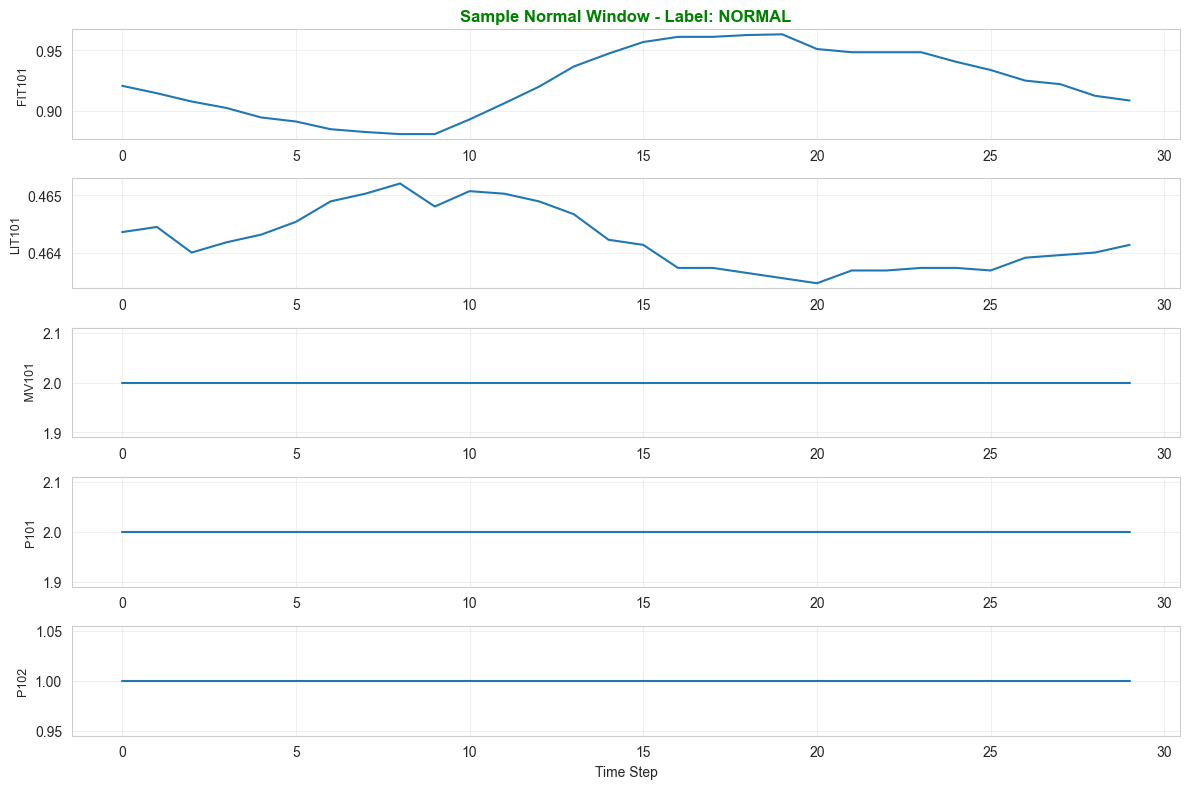

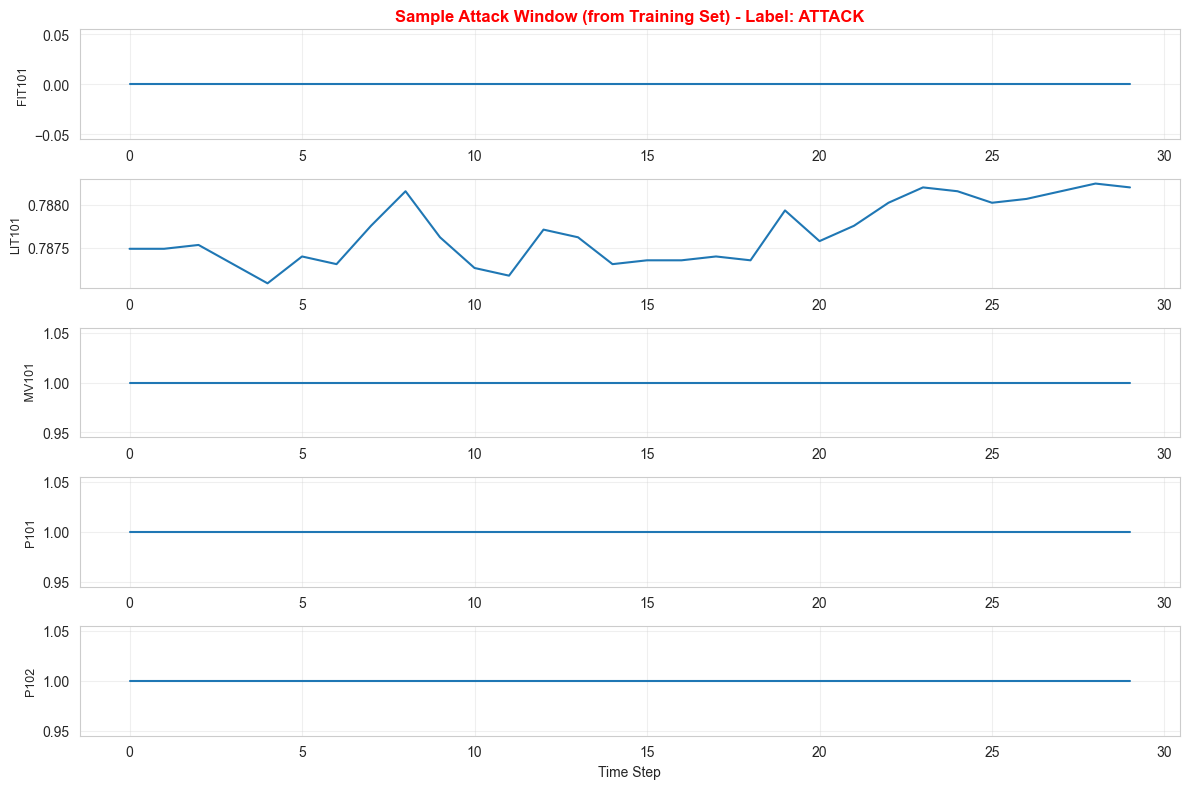

In [31]:
# Visualize a sample normal window and an attack window

def plot_sample_window(X_window, y_label, feature_names, title, n_features=5):
    """Plot time-series for a single window."""
    fig, axes = plt.subplots(n_features, 1, figsize=(12, 8))
    
    for i in range(n_features):
        axes[i].plot(X_window[:, i], linewidth=1.5)
        axes[i].set_ylabel(feature_names[i], fontsize=9)
        axes[i].grid(alpha=0.3)
        
        if i == 0:
            label_text = "ATTACK" if y_label == 1 else "NORMAL"
            color = 'red' if y_label == 1 else 'green'
            axes[i].set_title(f'{title} - Label: {label_text}', 
                            fontweight='bold', color=color, fontsize=12)
        
        if i == n_features - 1:
            axes[i].set_xlabel('Time Step', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Find a normal window
normal_idx = np.where(y_train == 0)[0][0]
plot_sample_window(X_train[normal_idx], y_train[normal_idx], 
                   modeling_features, "Sample Normal Window")

# Find an attack window (check train first, then test)
attack_indices_train = np.where(y_train == 1)[0]
if len(attack_indices_train) > 0:
    # Attack samples found in training set
    attack_idx = attack_indices_train[0]
    plot_sample_window(X_train[attack_idx], y_train[attack_idx], 
                       modeling_features, "Sample Attack Window (from Training Set)")
else:
    # No attack samples in training set, use test set
    print("⚠️  No attack samples in training set (unexpected with stratified split!)")
    print("Displaying attack sample from test set instead:\n")
    attack_indices_test = np.where(y_test == 1)[0]
    if len(attack_indices_test) > 0:
        attack_idx = attack_indices_test[0]
        plot_sample_window(X_test[attack_idx], y_test[attack_idx], 
                           modeling_features, "Sample Attack Window (from Test Set)")
    else:
        print("❌ No attack samples found in either train or test set!")


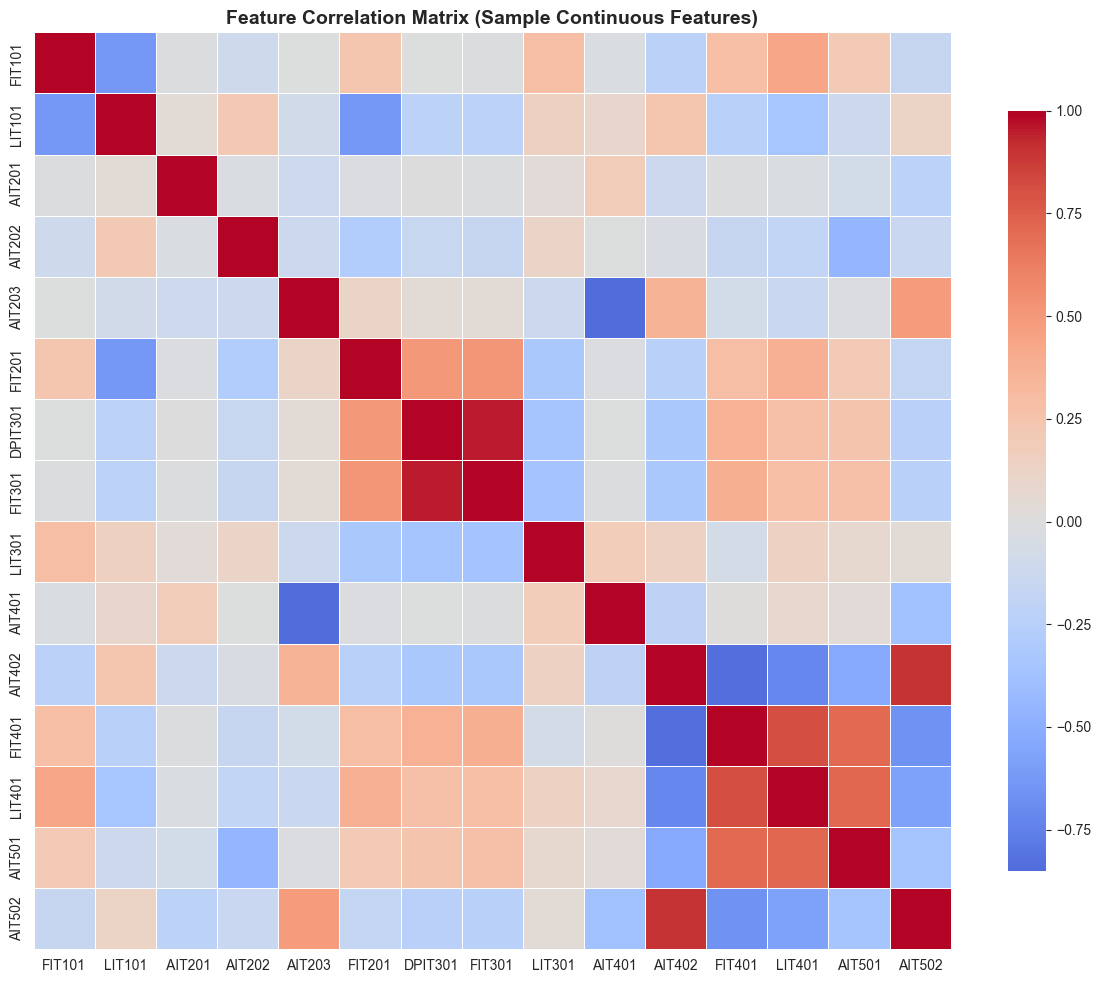


High correlations (|r| > 0.7) indicate:
  - Redundant sensors (can be reduced)
  - Physical coupling between process stages
  - Potential multicollinearity for some ML models


In [32]:
# Visualize feature correlation matrix (on sample of continuous features)

sample_features_corr = continuous_features[:15]

correlation_matrix = df_scaled[sample_features_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (Sample Continuous Features)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nHigh correlations (|r| > 0.7) indicate:")
print("  - Redundant sensors (can be reduced)")
print("  - Physical coupling between process stages")
print("  - Potential multicollinearity for some ML models")

---

## 10. Summary 

### 10.1 Accomplishments

In this notebook, we successfully:

1. **Loaded SWaT dataset** (time-series sensor/actuator data)
2. **Categorized features** by type (sensors, actuators) and process stage (P1-P6)
3. **Cleaned data** (handled missing values, removed duplicates)
4. **Engineered temporal features** (rate of change, rolling statistics)
5. **Normalized continuous features** (MinMaxScaler, preserved binary actuators)
6. **Created sliding windows** for LSTM input (30-step sequences)
7. **Split train/test** (temporal split: 70-30)
8. **Saved preprocessed data** for model training

### 10.2 Key Preprocessing Decisions

| Decision | Rationale |
|----------|-----------|
| **Forward-fill missing values** | CPS sensors tend to hold last valid reading during brief communication losses |
| **No outlier removal** | Outliers may indicate attacks; removing them would bias adversarial learning |
| **MinMaxScaler for sensors** | Respects physical bounds; better for bounded sensor ranges |
| **No scaling for actuators** | Binary states (0/1) are meaningful and should not be normalized |
| **Window size = 30 steps** | Captures ~30 seconds of process dynamics; adjustable based on attack duration |
| **Temporal split** | Prevents data leakage; respects chronological order of CPS operations |

### 10.3 Data Quality Metrics


In [33]:
# Display final dataset statistics and quality metrics

print("="*80)
print("FINAL DATASET STATISTICS")
print("="*80)

print(f"\n Windowed Data Overview:")
print(f"  • Total windows created: {X_windows.shape[0]:,}")
print(f"  • Training windows: {X_train.shape[0]:,}")
print(f"  • Test windows: {X_test.shape[0]:,}")
print(f"  • Features per window: {X_train.shape[2]}")
print(f"  • Time steps per window: {X_train.shape[1]}")

print(f"\n  Class Imbalance Analysis:")
train_attack_pct = (np.sum(y_train == 1) / len(y_train)) * 100
test_attack_pct = (np.sum(y_test == 1) / len(y_test)) * 100

print(f"  Training Set:")
print(f"    - Normal: {np.sum(y_train == 0):,} windows ({100 - train_attack_pct:.2f}%)")
print(f"    - Attack: {np.sum(y_train == 1):,} windows ({train_attack_pct:.2f}%)")

print(f"  Test Set:")
print(f"    - Normal: {np.sum(y_test == 0):,} windows ({100 - test_attack_pct:.2f}%)")
print(f"    - Attack: {np.sum(y_test == 1):,} windows ({test_attack_pct:.2f}%)")

print(f"\n All preprocessing complete - data ready for LSTM training")
print("="*80)


FINAL DATASET STATISTICS

 Windowed Data Overview:
  • Total windows created: 946,699
  • Training windows: 662,689
  • Test windows: 284,010
  • Features per window: 51
  • Time steps per window: 30

  Class Imbalance Analysis:
  Training Set:
    - Normal: 624,454 windows (94.23%)
    - Attack: 38,235 windows (5.77%)
  Test Set:
    - Normal: 267,624 windows (94.23%)
    - Attack: 16,386 windows (5.77%)

 All preprocessing complete - data ready for LSTM training


---

**End of Notebook 1**


In [34]:
# Final verification: Load saved data to ensure integrity

print("Verifying saved data integrity...\n")

X_train_loaded = np.load(f'{output_dir}/X_train.npy')
X_test_loaded = np.load(f'{output_dir}/X_test.npy')
y_train_loaded = np.load(f'{output_dir}/y_train.npy')
y_test_loaded = np.load(f'{output_dir}/y_test.npy')

assert X_train_loaded.shape == X_train.shape, "X_train shape mismatch"
assert X_test_loaded.shape == X_test.shape, "X_test shape mismatch"
assert y_train_loaded.shape == y_train.shape, "y_train shape mismatch"
assert y_test_loaded.shape == y_test.shape, "y_test shape mismatch"

print("✓ All data integrity checks passed")
print("\nPreprocessed data is ready for LSTM training in Notebook 2.")

Verifying saved data integrity...

✓ All data integrity checks passed

Preprocessed data is ready for LSTM training in Notebook 2.
